# FET concentration–response analysis: LC50 and EC50

This notebook reproduces the analyses performed in the legacy notebooks `LC50 - pt.ipynb` and `EC50 - pt.ipynb`, while making every inherited filtering decision explicit. Raw treatment codes are preserved as BCT/BST and recoded only for presentation: **BCT → SCB** and **BST → SCF**.

The legacy confidence intervals are covariance-based Student-t intervals for parameter `c`. They are reproduced for historical consistency and should not be interpreted as profile-likelihood or bootstrap intervals.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.optimize import curve_fit
from scipy.stats import t

ARTICLE_DIR = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RAW_FILE = ARTICLE_DIR / 'data' / 'raw' / 'fet_concentration_response' / 'dataset_todos_fet.xlsx'
ANALYSIS_FIGURES = ARTICLE_DIR / 'results' / 'figures'
MANUSCRIPT_IMAGES = ARTICLE_DIR / 'artigo_andre_tcc' / 'images'
ANALYSIS_FIGURES.mkdir(parents=True, exist_ok=True)
MANUSCRIPT_IMAGES.mkdir(parents=True, exist_ok=True)
RAW_FILE

WindowsPath('D:/OneDrive/backup ilum/TCC/article/data/raw/fet_concentration_response/dataset_todos_fet.xlsx')

## Exact legacy filtering rules

The following rules intentionally reproduce the old notebooks, including their inconsistencies:

- **SCB LC50:** remove rows where `remove == 1`, then drop original DataFrame index `2`.
- **SCF LC50:** exclude concentration 10 CB/L, remove rows where `remove == 1`, then drop original index `3`.
- **SCB EC50 (72 and 96 hpf):** remove rows where `remove == 1`, then drop original index `2`.
- **SCF EC50 (72 and 96 hpf):** exclude concentration 10 CB/L and drop original index `3`; the old EC50 notebook did **not** filter `remove == 1` for SCF.

Dropping rows by index is fragile because it depends on workbook order. It is retained solely to reproduce the historical result. The audit table below records which rows were removed.

In [2]:
raw_bct = pd.read_excel(RAW_FILE, sheet_name='BCT')
raw_bst = pd.read_excel(RAW_FILE, sheet_name='BST')

def legacy_filters(raw_bct, raw_bst):
    scb_lc = raw_bct.loc[raw_bct['remove'] != 1].drop(index=2).copy()
    scf_lc = raw_bst.loc[raw_bst['B/L'] != 10]
    scf_lc = scf_lc.loc[scf_lc['remove'] != 1].drop(index=3).copy()

    scb_ec = raw_bct.loc[raw_bct['remove'] != 1].drop(index=2).copy()
    scf_ec = raw_bst.loc[raw_bst['B/L'] != 10].drop(index=3).copy()
    return {'SCB_LC50': scb_lc, 'SCF_LC50': scf_lc, 'SCB_EC50': scb_ec, 'SCF_EC50': scf_ec}

datasets = legacy_filters(raw_bct, raw_bst)
for name, frame in datasets.items():
    frame['treatment'] = name[:3]  # presentation label only
    frame['concentration_cb_l'] = frame['B/L'].astype(float)
    print(name, 'included rows:', len(frame), 'original indices:', frame.index.tolist())

SCB_LC50 included rows: 27 original indices: [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 15, 16, 17, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
SCF_LC50 included rows: 31 original indices: [1, 2, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
SCB_EC50 included rows: 27 original indices: [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 15, 16, 17, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
SCF_EC50 included rows: 32 original indices: [1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]


In [3]:
# Explicit audit of exclusions relative to each raw worksheet.
audit = []
for analysis, frame in datasets.items():
    raw = raw_bct if analysis.startswith('SCB') else raw_bst
    for idx, row in raw.iterrows():
        audit.append({
            'analysis': analysis,
            'original_index': idx,
            'concentration_cb_l': row['B/L'],
            'date_start': row.get('date_start'),
            'remove_flag': row.get('remove'),
            'observation': row.get('observation'),
            'included_by_legacy_rule': idx in frame.index,
        })
audit = pd.DataFrame(audit)
audit.loc[~audit['included_by_legacy_rule']].sort_values(['analysis', 'original_index'])

,analysis,original_index,concentration_cb_l,date_start,remove_flag,observation,included_by_legacy_rule
69,SCB_EC50,2,8.0,06/10,0.0,NaN,False
79,SCB_EC50,12,3.0,14/07,1.0,NaN,False
80,SCB_EC50,13,3.0,28/08,1.0,premium,False
81,SCB_EC50,14,3.0,11/09,1.0,NaN,False
85,SCB_EC50,18,2.0,15/08,1.0,premium,False
86,SCB_EC50,19,2.0,15/08,1.0,premium,False
2,SCB_LC50,2,8.0,06/10,0.0,NaN,False
12,SCB_LC50,12,3.0,14/07,1.0,NaN,False
13,SCB_LC50,13,3.0,28/08,1.0,premium,False
14,SCB_LC50,14,3.0,11/09,1.0,NaN,False


## Response preparation and legacy four-parameter log-logistic model

Mortality is `mortality / total_eggs`. Hatching is reproduced as `72hpf / total_eggs` or `96hpf / total_eggs`, exactly as in the old notebooks. The model is `d + (a-d)/(1+(x/c)^b)`, where `c` was reported as LC50 or EC50.

In [4]:
def loglogistic(x, a, b, c, d):
    return d + (a - d) / (1 + (x / c) ** b)

def fit_legacy(frame, response_column):
    x = frame['concentration_cb_l'].to_numpy(float)
    y = frame[response_column].to_numpy(float)
    popt, pcov = curve_fit(loglogistic, x, y, p0=[1, 3, 2, 0],
                           bounds=([0, 0, 0, 0], [1, 10, 100, 1]))
    error = np.sqrt(np.diag(pcov))[2]
    t_value = t.ppf(0.975, len(x) - len(popt))
    estimate = popt[2]
    return popt, (estimate - t_value * error, estimate + t_value * error)

for name, frame in datasets.items():
    frame['mortality_rate'] = frame['mortality'] / frame['total_eggs']
    frame['hatching_72h_rate'] = frame['72hpf'] / frame['total_eggs']
    frame['hatching_96h_rate'] = frame['96hpf'] / frame['total_eggs']

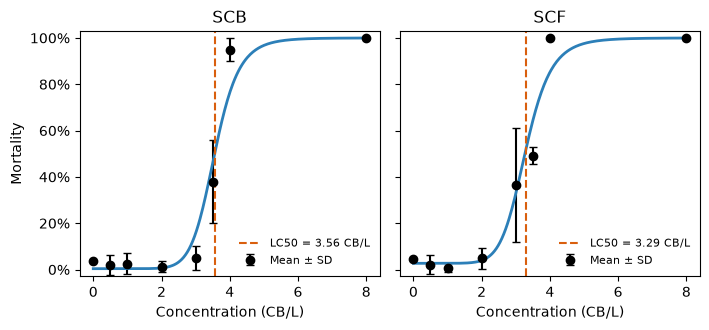

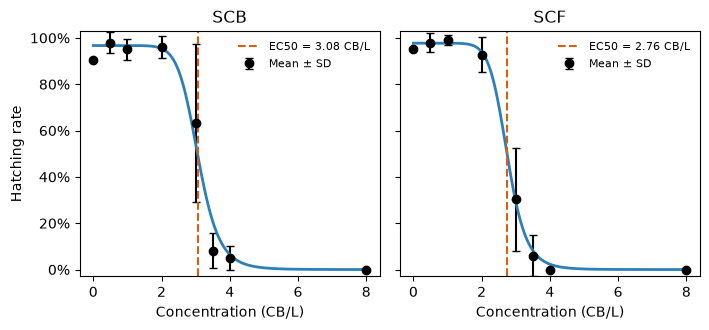

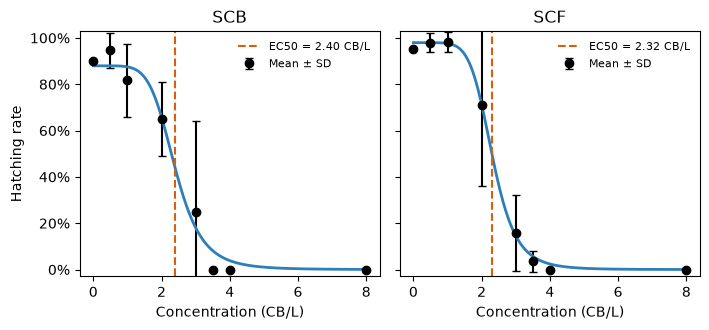

,treatment,endpoint,LC50,ci95_low,ci95_high,EC50
0,SCB,mortality_rate,3.559003,3.363045,3.754962,NaN
1,SCF,mortality_rate,3.289452,3.047837,3.531067,NaN
2,SCB,hatching_96h_rate,NaN,2.868183,3.282565,3.075374
3,SCF,hatching_96h_rate,NaN,2.565369,2.948893,2.757131
4,SCB,hatching_72h_rate,NaN,1.947957,2.847130,2.397544
5,SCF,hatching_72h_rate,NaN,1.994494,2.635934,2.315214


In [5]:
def plot_pair(names, response, metric, filename, ylabel):
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.4), sharey=True)
    rows = []
    for ax, name in zip(axes, names):
        frame = datasets[name]
        fit, ci = fit_legacy(frame, response)
        estimate = fit[2]
        grouped = frame.groupby('concentration_cb_l')[response].agg(['mean', 'std']).reset_index()
        x_fit = np.linspace(frame['concentration_cb_l'].min(), frame['concentration_cb_l'].max(), 300)
        ax.errorbar(grouped['concentration_cb_l'], grouped['mean'], yerr=grouped['std'],
                    fmt='o', color='black', capsize=3, label='Mean ± SD')
        ax.plot(x_fit, loglogistic(x_fit, *fit), color='#2C7FB8', lw=2)
        ax.axvline(estimate, color='#D95F0E', ls='--', lw=1.5,
                   label=f'{metric} = {estimate:.2f} CB/L')
        ax.set(title=name[:3], xlabel='Concentration (CB/L)', ylim=(-0.03, 1.03))
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.legend(frameon=False, fontsize=11, handlelength=1.8, labelspacing=0.5)
        rows.append({'treatment': name[:3], 'endpoint': response, metric: estimate,
                     'ci95_low': ci[0], 'ci95_high': ci[1]})
    axes[0].set_ylabel(ylabel)
    fig.tight_layout()
    for folder in [ANALYSIS_FIGURES, MANUSCRIPT_IMAGES]:
        fig.savefig(folder / f'{filename}.pdf', bbox_inches='tight')
        fig.savefig(folder / f'{filename}.png', dpi=600, bbox_inches='tight')
    plt.show()
    return pd.DataFrame(rows)

lc50 = plot_pair(['SCB_LC50', 'SCF_LC50'], 'mortality_rate', 'LC50',
                 'lc50_96h', 'Mortality')
ec50_96 = plot_pair(['SCB_EC50', 'SCF_EC50'], 'hatching_96h_rate', 'EC50',
                    'ec50_hatching_96h', 'Hatching rate')
ec50_72 = plot_pair(['SCB_EC50', 'SCF_EC50'], 'hatching_72h_rate', 'EC50',
                    'ec50_hatching_72h', 'Hatching rate')
pd.concat([lc50, ec50_96, ec50_72], ignore_index=True)

## Historical reference values

The stored outputs of the old notebooks reported: SCB LC50 = 3.5590 (95% CI 3.3630–3.7550), SCF LC50 = 3.2894 (3.0478–3.5311), SCB EC50 at 96 hpf = 3.0754 (2.8682–3.2826), SCF EC50 at 96 hpf = 2.7571 (2.5654–2.9489), SCB EC50 at 72 hpf = 2.3975 (1.9480–2.8471), and SCF EC50 at 72 hpf = 2.2854 (1.8413–2.7294). Re-executed results should be compared with these values.